# Deteccion de fraude bancario

## Comprensión del problema

El objetivo del proyecto es identificar comportamientos anómalos en transacciones bancarias que puedan indicar posibles fraudes.

La base de datos contiene información sobre características de las transacciones, incluyendo:

- Monto de la transacción
- Duración de la transacción
- Número de intentos de login
- Canal de transacción
- Tipo de transacción
- Balance de la cuenta

Variables como monto_transaccion, intentos_login y duracion_transaccion podrían estar asociadas con comportamientos de riesgo.

## Exploración inicial de los datos

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [105]:
df = pd.read_csv("/content/bank_transactions_data_2_augmented_clean_2.csv")

In [106]:
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,TX000001,AC00128,14.09,4/11/2023 16:29,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21
1,TX000002,AC00455,376.24,6/27/2023 16:44,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91
2,TX000003,AC00019,126.29,7/10/2023 18:16,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35
3,TX000004,AC00070,184.50,5/5/2023 16:32,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06
4,TX000005,AC00411,13.45,10/16/2023 17:51,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40


In [107]:
df.shape

(50000, 15)

### Limpieza y preparación de datos.

In [108]:
df = df.rename(columns={
    'TransactionID': 'id_transaccion',
    'AccountID': 'id_cuenta',
    'TransactionAmount': 'monto_transaccion',
    'TransactionDate': 'fecha_transaccion',
    'TransactionType': 'tipo_transaccion',
    'Location': 'ubicacion',
    'DeviceID': 'id_dispositivo',
    'IP Address': 'direccion_ip',
    'MerchantID': 'id_comercio',
    'Channel': 'canal',
    'CustomerAge': 'edad_cliente',
    'CustomerOccupation': 'ocupacion_cliente',
    'TransactionDuration': 'duracion_transaccion',
    'LoginAttempts': 'intentos_login',
    'AccountBalance': 'saldo_cuenta',
    'Fraud': 'fraude'
})

In [109]:
df.isnull().sum()

,0
id_transaccion,0
id_cuenta,0
monto_transaccion,0
fecha_transaccion,0
tipo_transaccion,0
ubicacion,0
id_dispositivo,0
direccion_ip,0
id_comercio,0
canal,0


In [110]:
df.duplicated().sum()

np.int64(0)

In [111]:
df.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
id_transaccion,0
id_cuenta,0
monto_transaccion,0
fecha_transaccion,0
tipo_transaccion,0
ubicacion,0
id_dispositivo,0
direccion_ip,0
id_comercio,0
canal,0


In [112]:
df.describe()

,monto_transaccion,edad_cliente,duracion_transaccion,intentos_login,saldo_cuenta
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000
mean,297.872214,44.647600,118.965320,1.12684,5122.738301
std,292.818888,17.800293,70.000681,0.60936,3904.266887
min,0.240000,18.000000,10.000000,1.00000,101.250000
25%,82.897500,27.000000,63.000000,1.00000,1508.720000
50%,209.355000,45.000000,111.000000,1.00000,4735.410000
75%,409.625000,59.000000,161.000000,1.00000,7713.670000
max,2060.590000,80.000000,300.000000,5.00000,14977.990000


In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_transaccion        50000 non-null  object 
 1   id_cuenta             50000 non-null  object 
 2   monto_transaccion     50000 non-null  float64
 3   fecha_transaccion     50000 non-null  object 
 4   tipo_transaccion      50000 non-null  object 
 5   ubicacion             50000 non-null  object 
 6   id_dispositivo        50000 non-null  object 
 7   direccion_ip          50000 non-null  object 
 8   id_comercio           50000 non-null  object 
 9   canal                 50000 non-null  object 
 10  edad_cliente          50000 non-null  int64  
 11  ocupacion_cliente     50000 non-null  object 
 12  duracion_transaccion  50000 non-null  int64  
 13  intentos_login        50000 non-null  int64  
 14  saldo_cuenta          50000 non-null  float64
dtypes: float64(2), int6

El dataset presenta una estructura consistente, con variables numéricas y categóricas relevantes para el análisis de fraude. No se observan valores faltantes significativos ni duplicados que afecten la calidad de los datos.

#### Detección de fraudes

In [114]:
fraud_conditions = (
    (df['monto_transaccion'] > df['monto_transaccion'].quantile(0.95)) |
    (df['intentos_login'] > 2) |
    (df['duracion_transaccion'] > df['duracion_transaccion'].quantile(0.95))
)

df['fraude'] = fraud_conditions.astype(int)

In [115]:
df['fraude'].value_counts(normalize=True).mul(100).rename('proporcion')

,proporcion
fraude,
0,86.856
1,13.144


Se creó una variable de fraude basada en reglas heurísticas. Una transacción fue marcada como fraudulenta si el monto superaba el percentil 95, si el número de intentos de login era mayor a 2 o si la duración de la transacción superaba el percentil 95.

## Análisis exploratorio de datos

In [116]:
fraud_counts = df['fraude'].value_counts()
fraud_pct = df['fraude'].value_counts(normalize=True) * 100

print(f"\nClass Distribution:")
for label, count in fraud_counts.items():
    label_name = 'fraude' if label == 1 else 'Non-Fraud'
    print(f"   {label_name} ({label}): {count:,} ({fraud_pct[label]:.2f}%)")


Class Distribution:
   Non-Fraud (0): 43,428 (86.86%)
   fraude (1): 6,572 (13.14%)


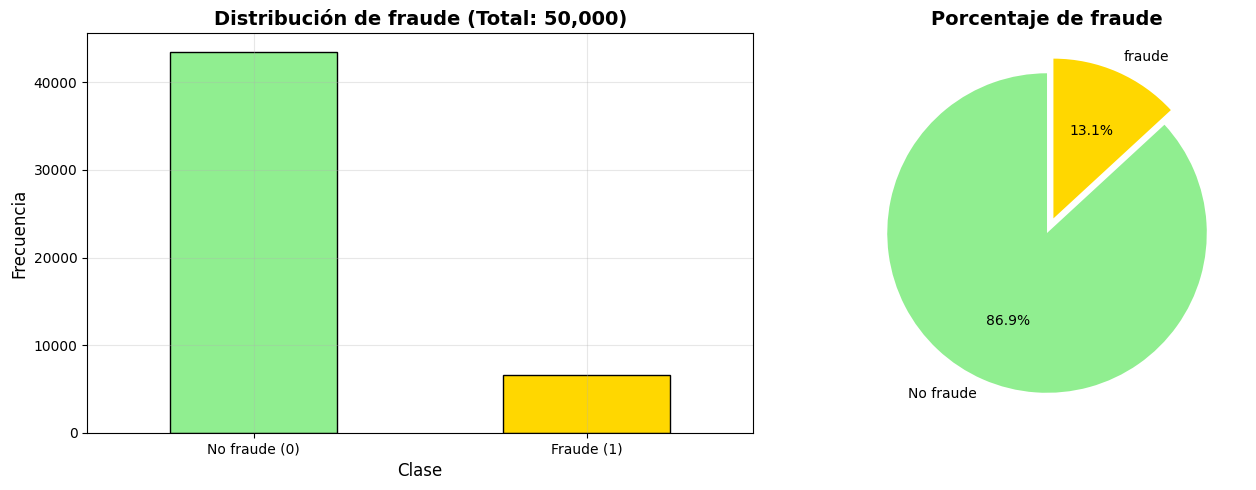

In [117]:
fraud_counts = df['fraude'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraud_counts.plot(kind='bar', color=['lightgreen', 'gold'], edgecolor='black', ax=axes[0])
axes[0].set_xlabel('Clase', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].set_title(f'Distribución de fraude (Total: {len(df):,})', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['No fraude (0)', 'Fraude (1)'], rotation=0)
axes[0].grid(alpha=0.3)

colors = ['lightgreen', 'gold']
axes[1].pie(fraud_counts, labels=['No fraude', 'fraude'], autopct='%1.1f%%',
            startangle=90, colors=colors, explode=(0, 0.1))
axes[1].set_title('Porcentaje de fraude', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### Distribución de las variables numéricas

In [118]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
numeric_cols

Index(['monto_transaccion', 'edad_cliente', 'duracion_transaccion',
       'intentos_login', 'saldo_cuenta', 'fraude'],
      dtype='object')

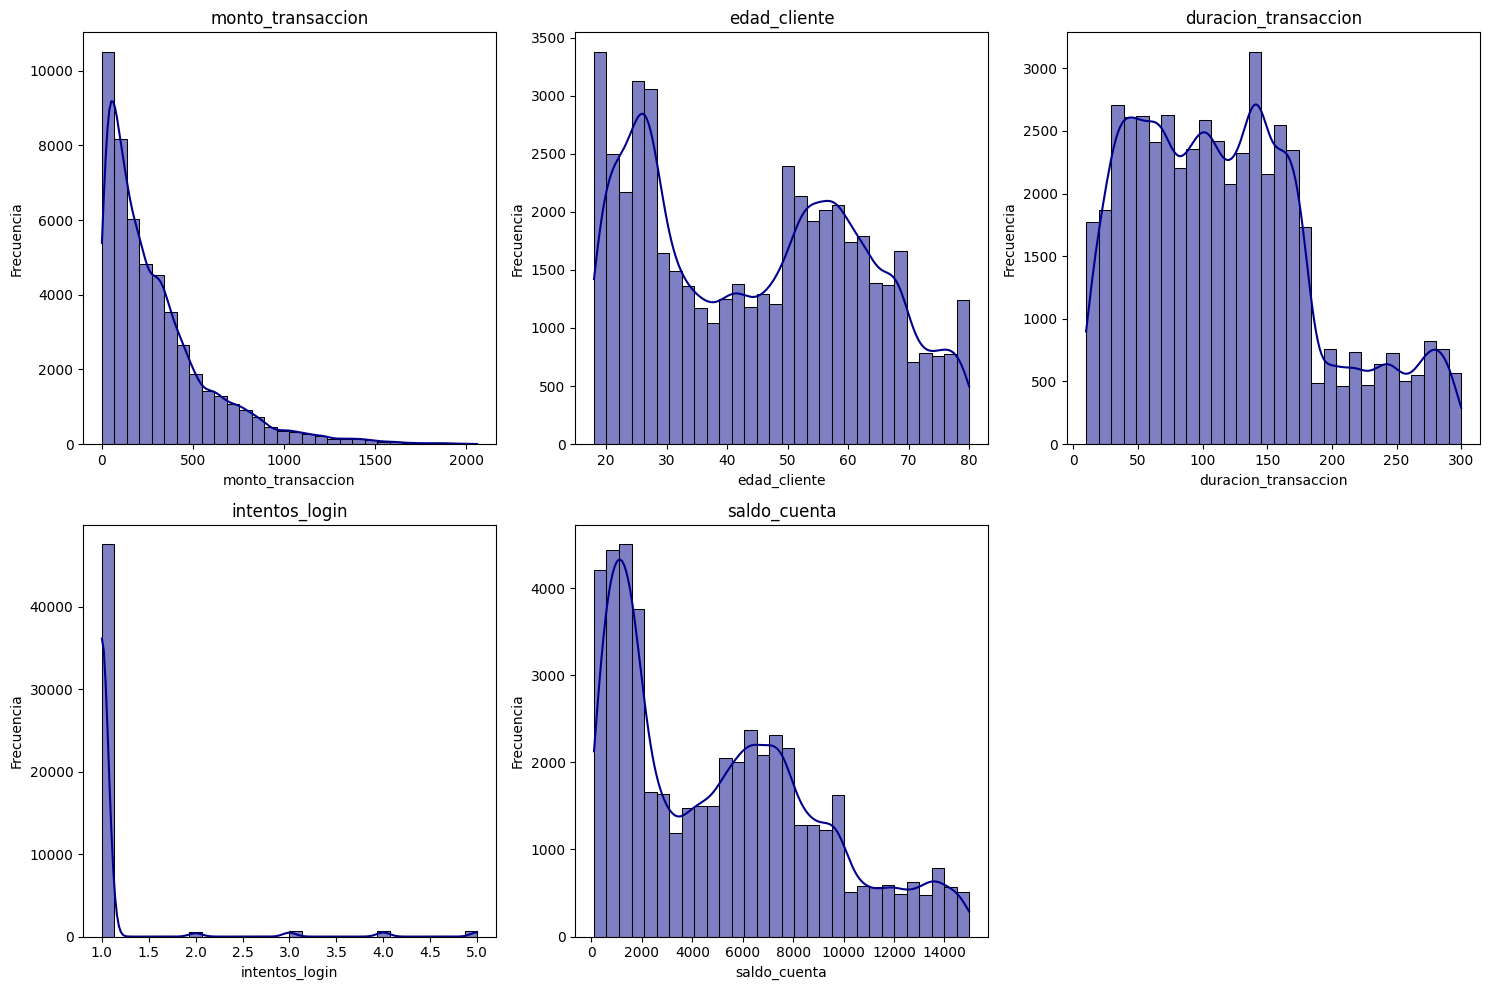

In [119]:
graph_var = ['monto_transaccion', 'edad_cliente', 'duracion_transaccion', 'intentos_login', 'saldo_cuenta']

n_cols = 3
n_rows = (len(graph_var) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 5*n_rows))

for i, col in enumerate(graph_var):
    plt.subplot(n_rows, n_cols, i+1)
    sns.histplot(df[col], bins=30, kde=True, color='darkblue')
    plt.title(f'{col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [120]:
fraud_amounts = df[df['fraude'] == 1]['monto_transaccion']
non_fraud_amounts = df[df['fraude'] == 0]['monto_transaccion']

print(f"Transacciones no fraudulenta:")
print(f"   Mean: ${non_fraud_amounts.mean():.2f}")
print(f"   Median: ${non_fraud_amounts.median():.2f}")
print(f"   Std: ${non_fraud_amounts.std():.2f}")

print(f"\nTransacción fraudulenta:")
print(f"   Mean: ${fraud_amounts.mean():.2f}")
print(f"   Median: ${fraud_amounts.median():.2f}")
print(f"   Std: ${fraud_amounts.std():.2f}")

Transacciones no fraudulenta:
   Mean: $254.00
   Median: $197.55
   Std: $213.80

Transacción fraudulenta:
   Mean: $587.76
   Median: $371.98
   Std: $503.55


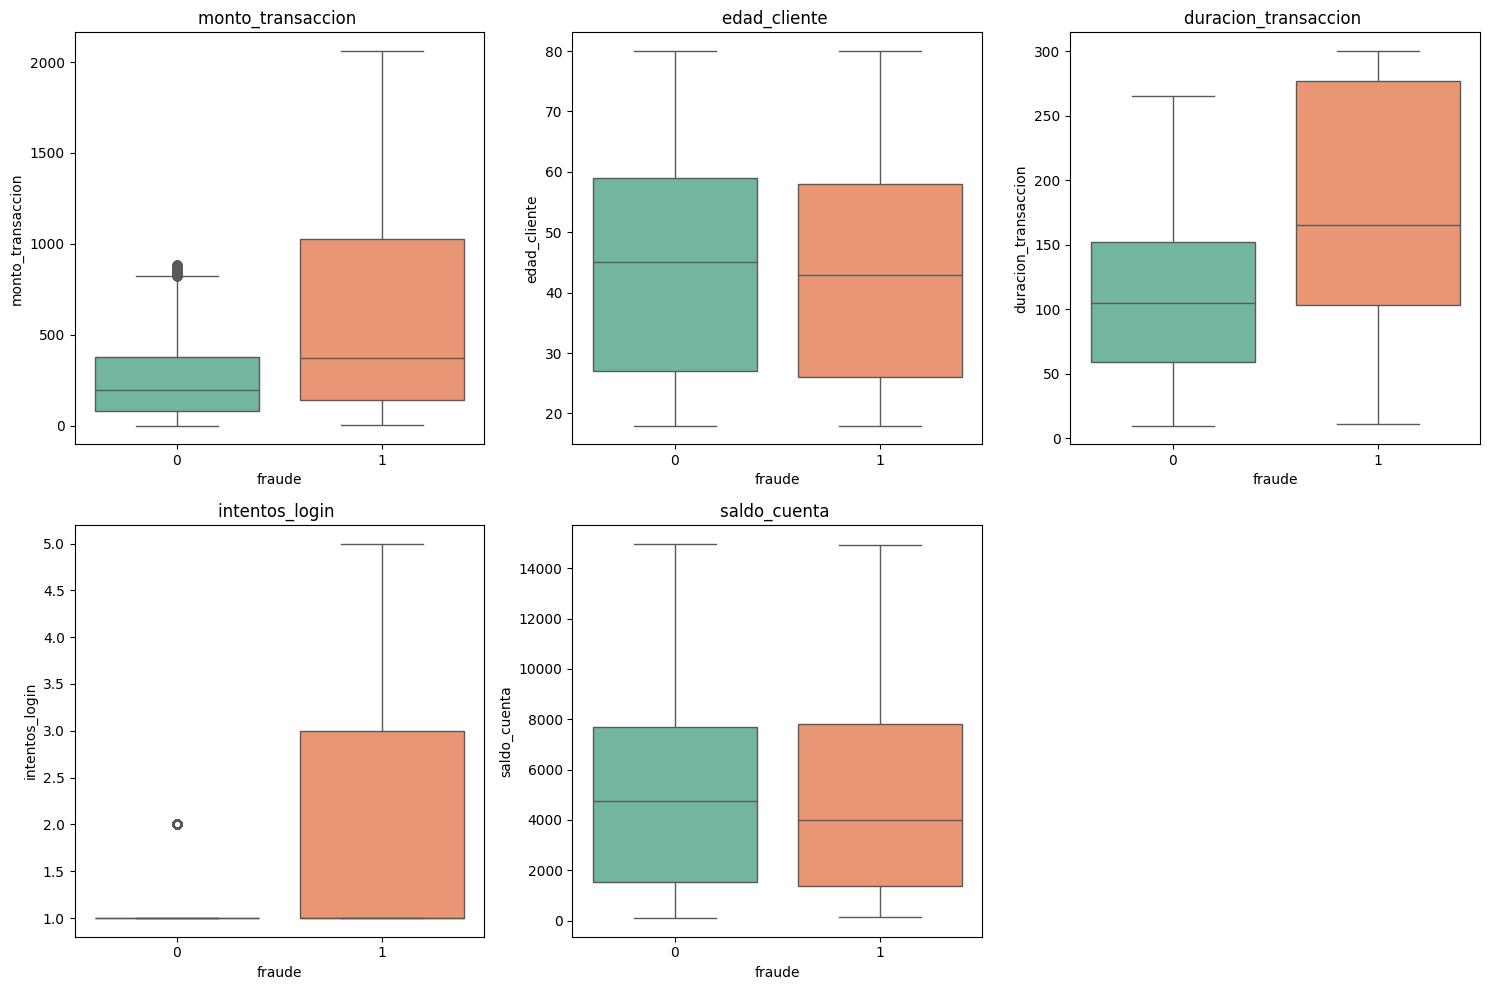

In [121]:
fig, axes = plt.subplots(2, 3, figsize=(15,10))
axes = axes.flatten()

for i, var in enumerate(graph_var):
    sns.boxplot(x='fraude', y=var, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f"{var} ")

for j in range(len(graph_var), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Se analizó la distribución de las variables numéricas mediante histogramas y boxplots. Los resultados muestran que algunas variables presentan distribuciones asimétricas y la presencia de valores atípicos, particularmente en el monto de las transacciones y el balance de las cuentas. Estos valores extremos podrían estar asociados con comportamientos inusuales en las transacciones y potenciales casos de fraude.

### Distribución variables categoricas

In [122]:
df['tipo_transaccion'].value_counts().rename('Frecuencia')

,Frecuencia
tipo_transaccion,
Debit,38747
Credit,11253


In [123]:
df['tipo_transaccion'] = df['tipo_transaccion'].replace({
    'Debit': 'Debito',
    'Credit': 'Credito'
})

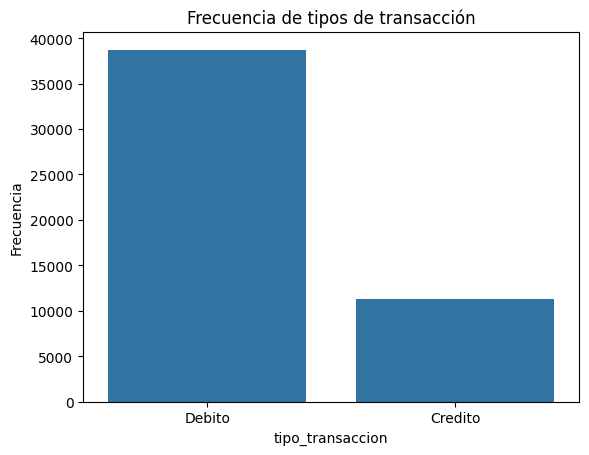

In [124]:
sns.countplot(x='tipo_transaccion', data=df)
plt.title("Frecuencia de tipos de transacción")
plt.ylabel('Frecuencia')
plt.show()

In [125]:
df['canal'].value_counts()

,count
canal,
Branch,17278
ATM,16552
Online,16170


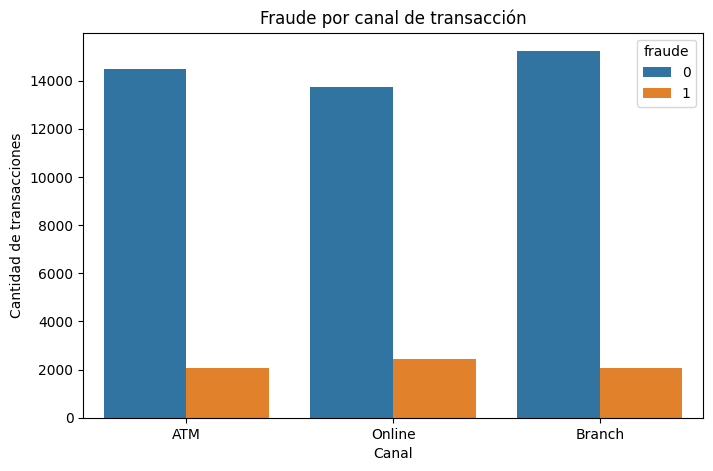

In [126]:
plt.figure(figsize=(8,5))

sns.countplot(x='canal', hue='fraude', data=df)

plt.title("Fraude por canal de transacción")
plt.xlabel("Canal")
plt.ylabel("Cantidad de transacciones")

plt.show()

In [127]:
df['ocupacion_cliente'].value_counts().rename('Frecuencia')

,Frecuencia
ocupacion_cliente,
Student,13059
Doctor,12578
Engineer,12491
Retired,11872


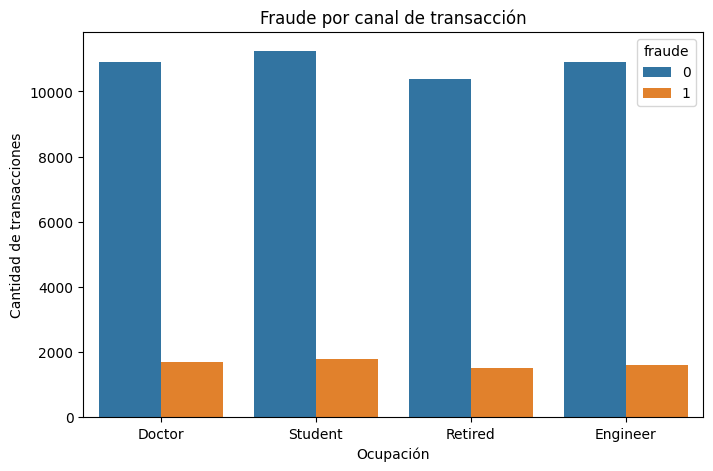

In [128]:
plt.figure(figsize=(8,5))

sns.countplot(x='ocupacion_cliente', hue='fraude', data=df)

plt.title("Fraude por canal de transacción")
plt.xlabel("Ocupación")
plt.ylabel("Cantidad de transacciones")

plt.show()

### Relaciones entre variables

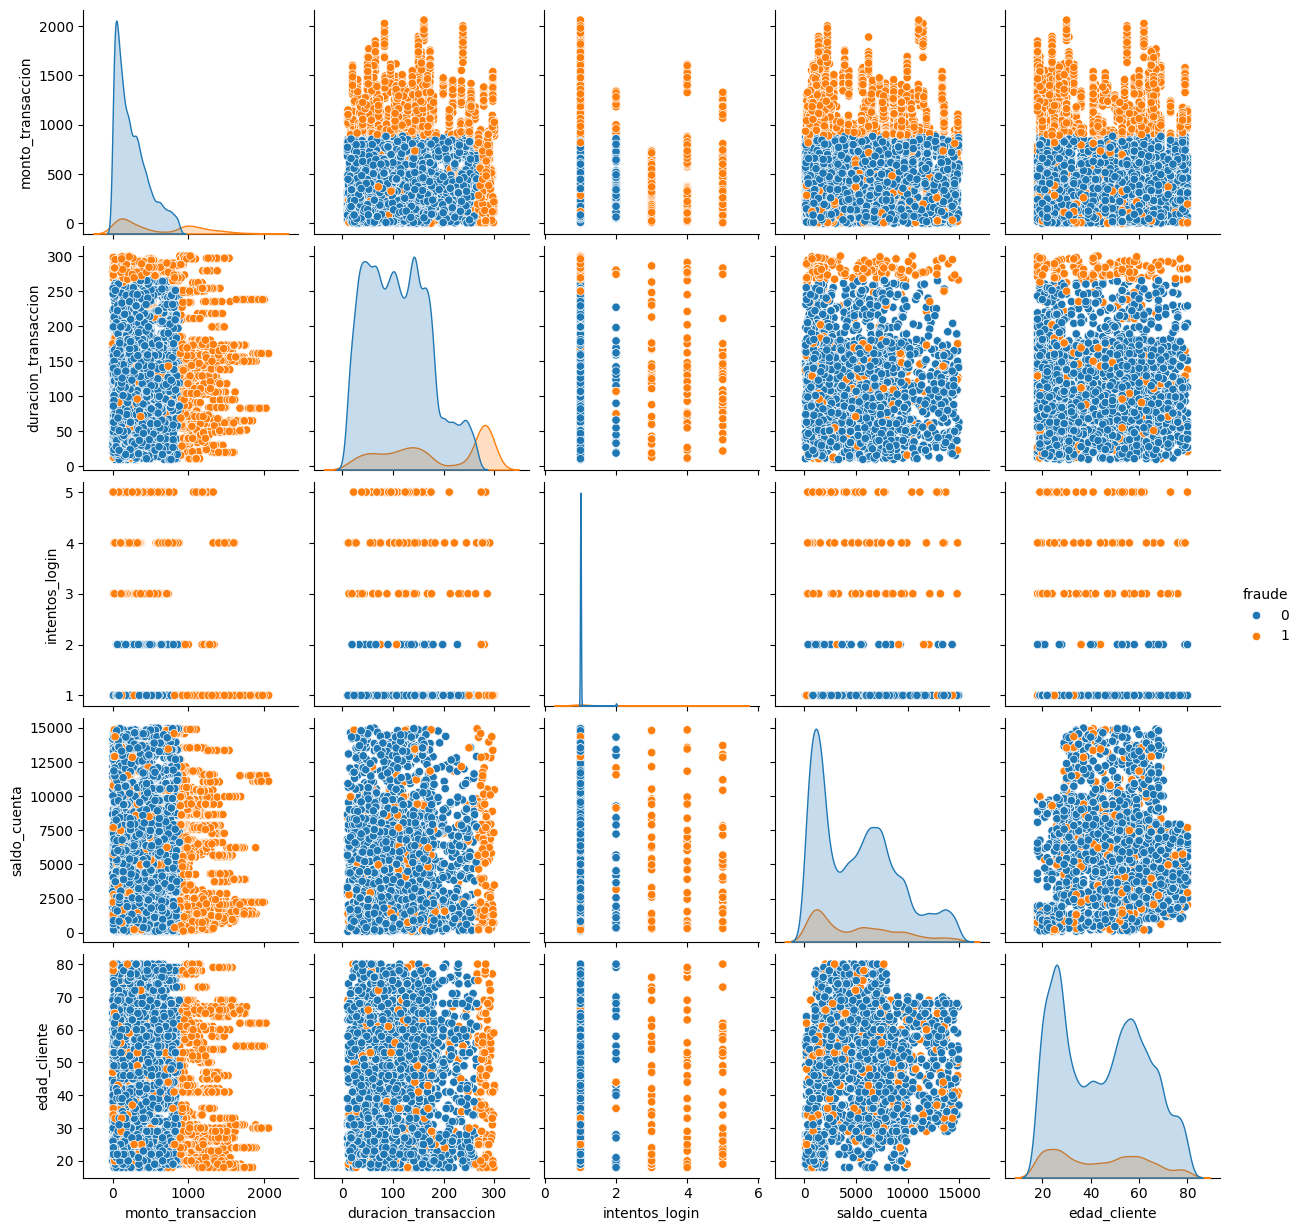

In [129]:
sns.pairplot(
    df[['monto_transaccion','duracion_transaccion','intentos_login','saldo_cuenta','edad_cliente','fraude']],
    hue='fraude'
)

plt.show()

Se exploraron las relaciones entre las variables numéricas y categóricas mediante matrices de correlación, gráficos de dispersión y análisis cruzado con la variable de fraude. Los resultados muestran que variables como el monto de la transacción, la duración de la transacción y el número de intentos de login presentan patrones asociados con comportamientos anómalos, lo que las convierte en variables relevantes para el análisis y la detección de posibles fraudes.

In [130]:
df.corr(numeric_only=True)

,monto_transaccion,edad_cliente,duracion_transaccion,intentos_login,saldo_cuenta,fraude
monto_transaccion,1.000000,-0.020924,0.013444,-0.015235,-0.021406,0.385121
edad_cliente,-0.020924,1.000000,-0.015324,0.007693,0.319942,-0.025975
duracion_transaccion,0.013444,-0.015324,1.000000,0.032914,0.006163,0.331819
intentos_login,-0.015235,0.007693,0.032914,1.000000,0.004979,0.490790
saldo_cuenta,-0.021406,0.319942,0.006163,0.004979,1.000000,-0.017002
fraude,0.385121,-0.025975,0.331819,0.490790,-0.017002,1.000000


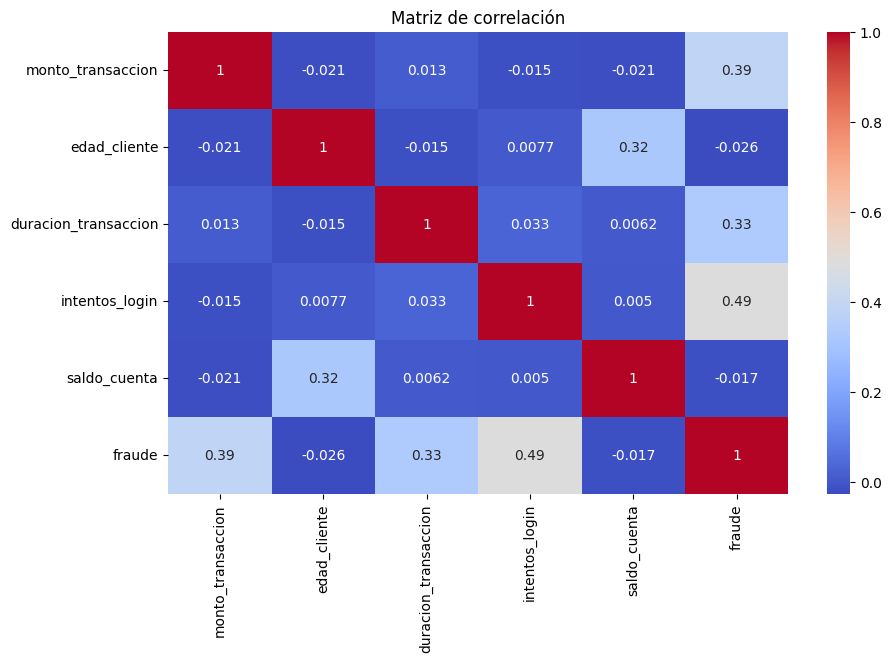

In [131]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

## Feature Engineering

In [132]:
#  La relación monto/saldo puede mostrar transacciones sospechosamente grandes.
df['ratio_monto_saldo'] = df['monto_transaccion'] / (df['saldo_cuenta'] + 1)

# Los cliente con muchos intentos de login pueden indicar actividad sospechosa.
df['muchos_intentos_login'] = df['intentos_login'] > 3

# Transacciónes rápidas y grandes. Las transacciones fraudulentas muchas veces son montos grandes en poco tiempo.
df['monto_por_duracion'] = df['monto_transaccion'] / (df['duracion_transaccion'] + 1)

# Cliente joven con transacción grande
df['monto_por_edad'] = df['monto_transaccion'] / df['edad_cliente']

# Cliente con saldo bajo pero transacción grande
df['transaccion_sospechosa'] = (
    df['monto_transaccion'] > df['saldo_cuenta'] * 0.8
)

#Categorizar monto de transacción. Crear niveles de monto ayuda a algunos modelos.
df['categoria_monto'] = pd.qcut(df['monto_transaccion'], q=4, labels=[
    'bajo', 'medio', 'alto', 'muy_alto'
])

# Cliente con alto riesgo. Se combinan dos comportamientos sospechosos.
df['riesgo_cliente'] = (
    (df['intentos_login'] > 3) &
    (df['monto_transaccion'] > df['monto_transaccion'].median())
)
# Monto promedio por ocupación. Esto permite ver si una transacción es alta para esa ocupación.
promedio_ocupacion = df.groupby('ocupacion_cliente')['monto_transaccion'].transform('mean')
df['ratio_monto_ocupacion'] = df['monto_transaccion'] / promedio_ocupacion

Se generaron nuevas variables derivadas con el objetivo de capturar patrones potencialmente asociados al fraude. Estas variables incluyen relaciones entre el monto de la transacción y el saldo disponible, métricas basadas en el comportamiento del cliente y variables indicadoras de actividad sospechosa, como múltiples intentos de acceso.

In [133]:
corr = df.corr(numeric_only=True)

corr['fraude'].sort_values(ascending=False)

,fraude
fraude,1.000000
intentos_login,0.490790
muchos_intentos_login,0.420823
monto_transaccion,0.385121
ratio_monto_ocupacion,0.384624
monto_por_edad,0.344402
duracion_transaccion,0.331819
riesgo_cliente,0.274571
monto_por_duracion,0.160025
transaccion_sospechosa,0.131905


In [134]:
variables_finales = [
    'intentos_login',
    'monto_transaccion',
    'duracion_transaccion',
    'ratio_monto_ocupacion',
    'monto_por_edad',
    'ratio_monto_saldo',
    'monto_por_duracion',
    'transaccion_sospechosa',
    'fraude'
]

df_modelo = df[variables_finales]

Se seleccionaron las variables con mayor correlación con la variable objetivo Fraud, priorizando aquellas relacionadas con el monto de la transacción, el número de intentos de login y métricas derivadas de comportamiento financiero.

### Detección de anomalías

##### Identificación de valores atípicos (outliers)

In [135]:
Q1 = df['monto_transaccion'].quantile(0.25)
Q3 = df['monto_transaccion'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['monto_transaccion'] < limite_inferior) |
              (df['monto_transaccion'] > limite_superior)]

print("Cantidad de outliers:", len(outliers))

Cantidad de outliers: 2375


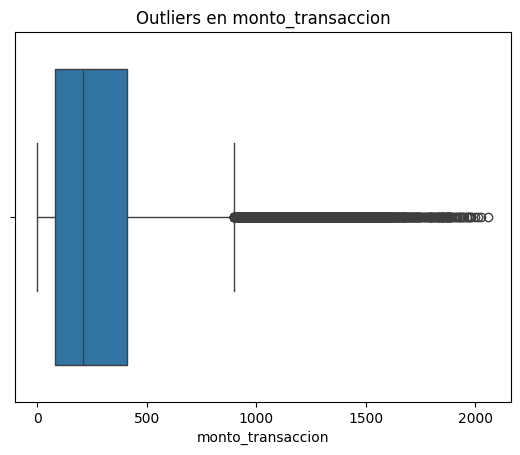

In [136]:
sns.boxplot(x=df['monto_transaccion'])
plt.title("Outliers en monto_transaccion")
plt.show()

Para detectar valores atípicos se utilizó el método del Rango Intercuartílico (IQR). Este método identifica observaciones que se encuentran fuera del rango definido por
𝑄
1
−
1.5
×
𝐼
𝑄
𝑅
Q1−1.5×IQR y
𝑄
3
+
1.5
×
𝐼
𝑄
𝑅
Q3+1.5×IQR.
Se aplicó principalmente sobre variables numéricas como el monto de la transacción, la duración y el saldo de la cuenta, ya que estas pueden presentar valores extremos asociados a comportamientos anómalos o potencialmente fraudulentos.

##### Detección de anomalías con Machine Learning

In [137]:
X = df_modelo.drop(columns=['fraude'])

In [138]:
from sklearn.ensemble import IsolationForest

modelo_anomalias = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

modelo_anomalias.fit(X)

df_modelo['anomalia'] = modelo_anomalias.predict(X)

In [139]:
df_modelo['anomalia'] = df_modelo['anomalia'].map({1:0, -1:1})

In [140]:
df_modelo['anomalia'].value_counts()

,count
anomalia,
0,47500
1,2500


In [141]:
pd.crosstab(df_modelo['fraude'], df_modelo['anomalia'])

anomalia,0,1
fraude,,
0,42586,842
1,4914,1658


0 → transacciones normales

1 → transacciones anómalas

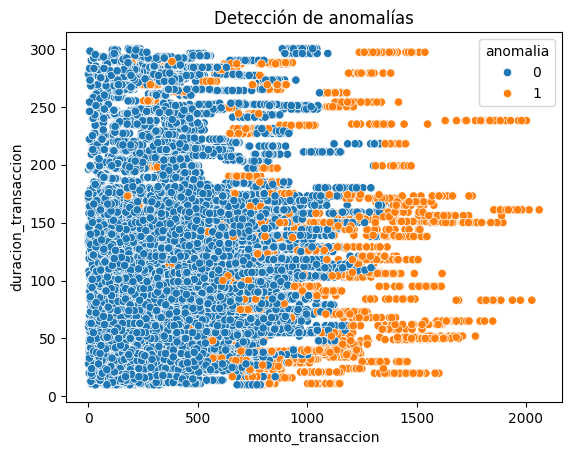

In [142]:
sns.scatterplot(
    x=df_modelo['monto_transaccion'],
    y=df_modelo['duracion_transaccion'],
    hue=df_modelo['anomalia']
)

plt.title("Detección de anomalías")
plt.show()

Para la detección de anomalías se aplicó el algoritmo Isolation Forest, un método de aprendizaje automático diseñado para identificar observaciones inusuales dentro de un conjunto de datos. Las observaciones clasificadas como anomalías pueden representar transacciones potencialmente fraudulentas o comportamientos financieros atípicos.

### Análisis de resultados

In [143]:
df_modelo.groupby('anomalia').mean(numeric_only=True)

,intentos_login,monto_transaccion,duracion_transaccion,ratio_monto_ocupacion,monto_por_edad,ratio_monto_saldo,monto_por_duracion,transaccion_sospechosa,fraude
anomalia,,,,,,,,,
0,1.123726,260.807641,118.671305,0.878106,6.770093,0.127461,3.401120,0.024253,0.103453
1,1.186000,1002.099100,124.551600,3.315986,34.160418,1.504119,14.742513,0.664000,0.663200


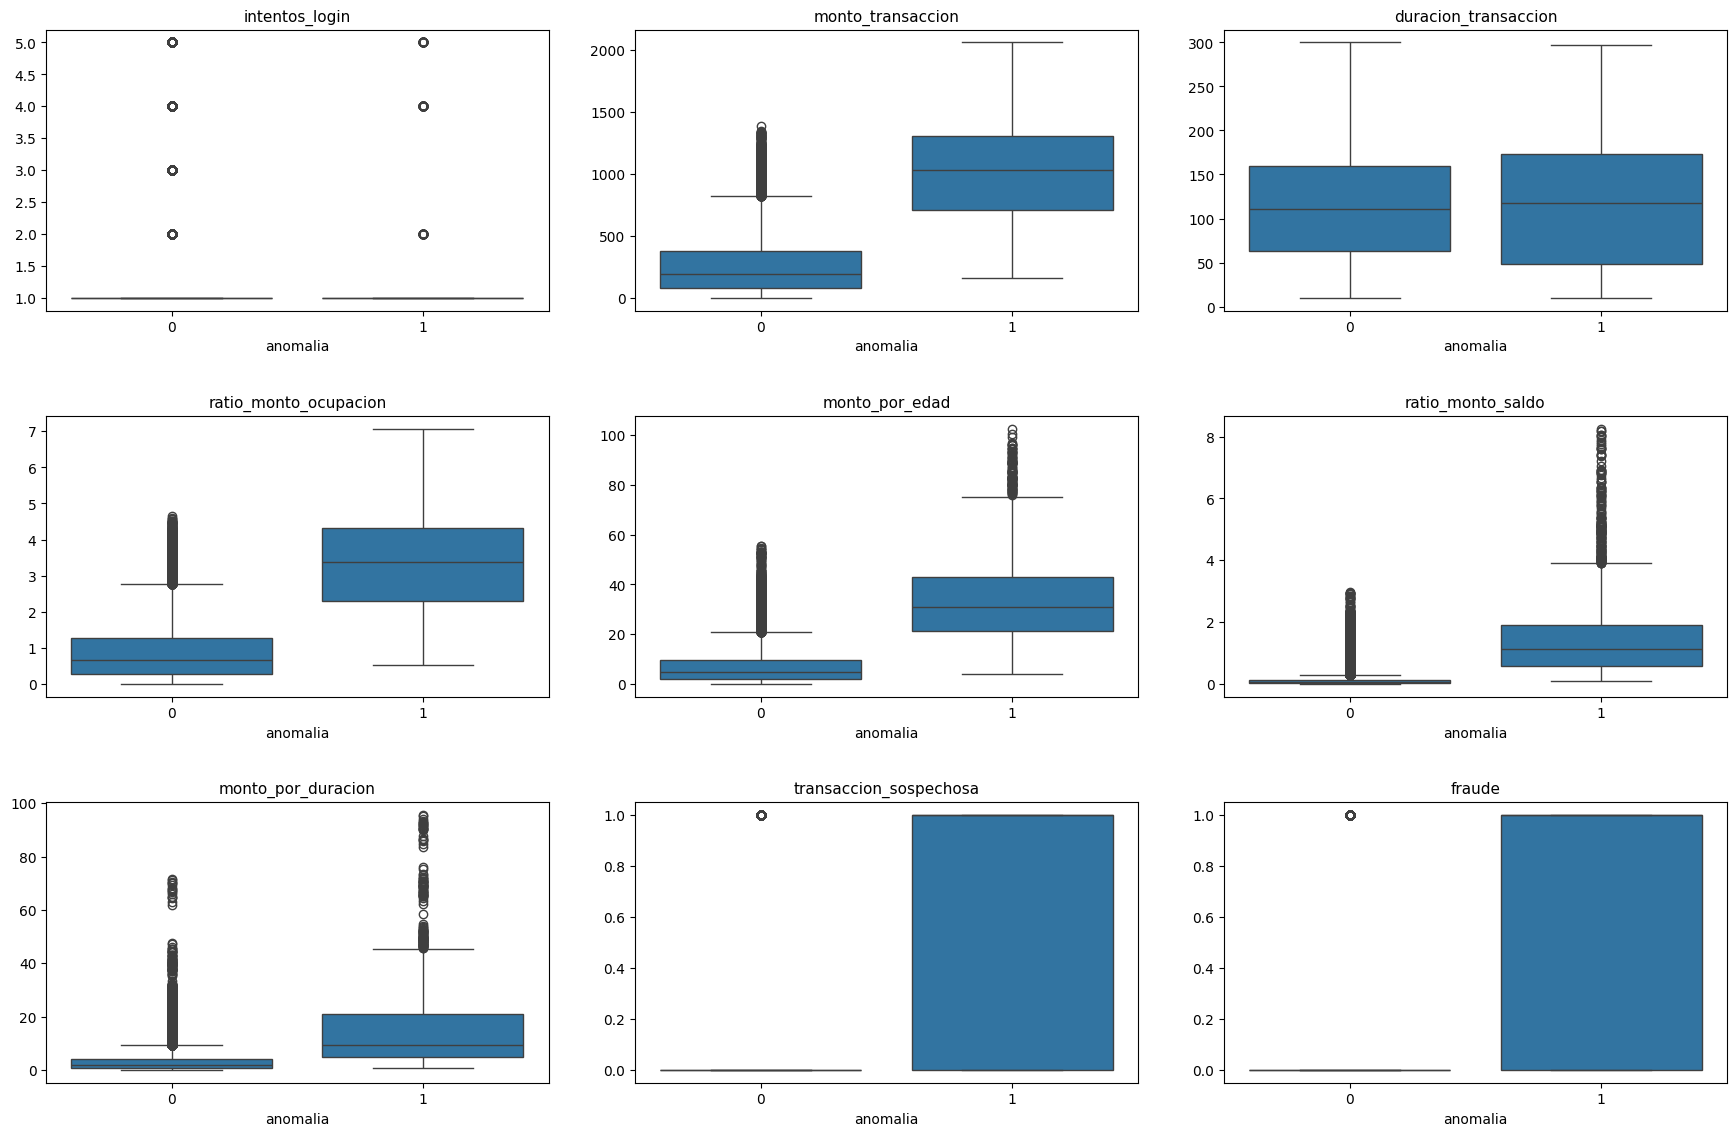

In [144]:
fig, axes = plt.subplots(3,3, figsize=(18,12))
axes = axes.flatten()

for i, var in enumerate(variables_finales):

    sns.boxplot(
        x='anomalia',
        y=var,
        data=df_modelo,
        ax=axes[i]
    )

    axes[i].set_title(var, fontsize=11)
    axes[i].set_xlabel("anomalia")
    axes[i].set_ylabel("")

plt.tight_layout(pad=3)
plt.show()

Se analizaron las características de las transacciones clasificadas como anómalas por el modelo de detección de anomalías. Se observó que estas transacciones tienden a presentar montos más elevados, mayor número de intentos de acceso y valores más altos en las métricas de riesgo generadas durante el proceso de ingeniería de variables. Además, se identificó que una proporción significativa de estas transacciones coincide con los registros de fraude presentes en el dataset, lo que sugiere que el modelo logra identificar comportamientos potencialmente sospechosos.

### Visualización e interpretación

In [145]:
df_modelo.groupby('anomalia').mean(numeric_only=True)

,intentos_login,monto_transaccion,duracion_transaccion,ratio_monto_ocupacion,monto_por_edad,ratio_monto_saldo,monto_por_duracion,transaccion_sospechosa,fraude
anomalia,,,,,,,,,
0,1.123726,260.807641,118.671305,0.878106,6.770093,0.127461,3.401120,0.024253,0.103453
1,1.186000,1002.099100,124.551600,3.315986,34.160418,1.504119,14.742513,0.664000,0.663200


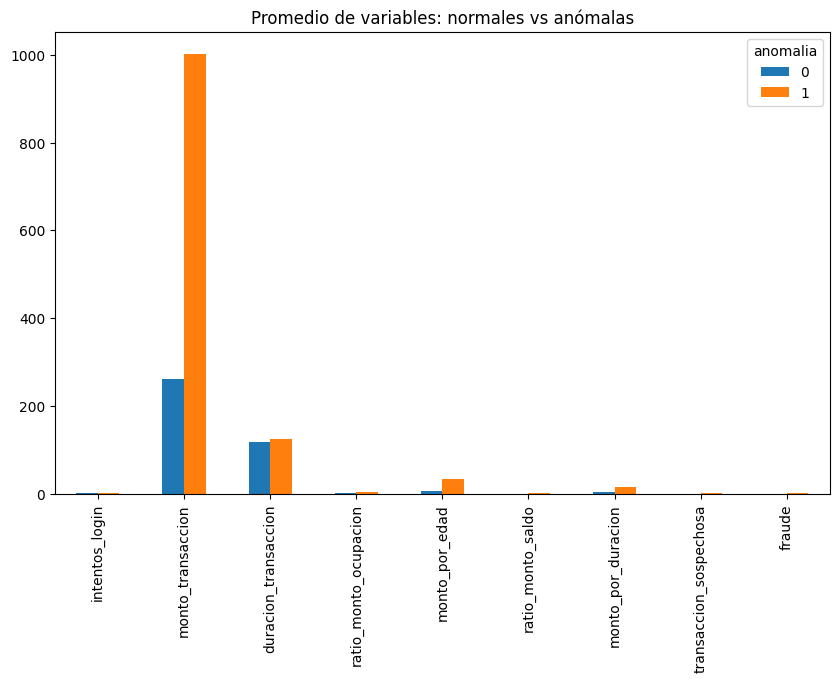

In [146]:
df_modelo.groupby('anomalia').mean(numeric_only=True).T.plot(kind='bar', figsize=(10,6))
plt.title("Promedio de variables: normales vs anómalas")
plt.show()

A partir del análisis de las transacciones clasificadas como anómalas, se identificó que las variables que presentan mayores diferencias respecto a las transacciones normales son el monto de la transacción y la duración. Estas variables parecen ser las que más influyen en la detección de anomalías por parte del modelo.

#📌 Conclusiones
##🔍 Principales hallazgos

A partir del análisis exploratorio y la detección de anomalías, se identificaron diferencias claras entre las transacciones normales y las sospechosas. En particular, las transacciones anómalas tienden a presentar valores atípicos en variables clave como el monto, la frecuencia de operaciones y los intentos de acceso.

Además, los métodos aplicados permitieron detectar patrones que no son evidentes a simple vista, lo que demuestra la utilidad de las técnicas de detección de anomalías en contextos financieros.

##⚠️ Patrones relevantes para el negocio

Se observaron los siguientes comportamientos asociados a mayor riesgo:

Transacciones con montos significativamente más altos que el promedio.

Mayor cantidad de intentos de login fallidos antes de una operación.

Frecuencia inusual de transacciones en períodos cortos de tiempo.

Combinaciones de variables que, en conjunto, representan comportamientos atípicos aunque individualmente no lo parezcan.

Estos patrones son consistentes con posibles escenarios de fraude o uso indebido de cuentas.

##💡  Recomendaciones

En base a los resultados obtenidos, se sugieren las siguientes acciones:

Implementar sistemas automáticos de monitoreo que utilicen modelos de detección de anomalías para identificar transacciones sospechosas en tiempo real.

Establecer alertas para transacciones que superen ciertos umbrales de riesgo (por ejemplo, montos elevados o múltiples intentos fallidos de acceso).

Incorporar variables derivadas (feature engineering) que permitan mejorar la capacidad predictiva de los modelos.

Realizar revisiones periódicas de los patrones detectados para ajustar los criterios de detección y adaptarse a nuevos comportamientos fraudulentos.

##✅  Cierre

El análisis realizado demuestra que es posible identificar comportamientos anómalos relevantes a partir de los datos disponibles. La aplicación de técnicas de análisis exploratorio y machine learning permite no solo detectar posibles fraudes, sino también comprender mejor los factores que los explican, lo cual es clave para la toma de decisiones en el negocio.